# L9.1 — LLM Observability (traces, metrics, logs)

Hands-on notebook for the lesson [`9-1-observability.mdx`](../../llm-quest-theory/level-9/9-1-observability.mdx).

> **Learning objectives**
> - Design a **log schema** specific to LLM apps — model, tokens in/out, latency, cost, feedback.
> - Instrument a toy RAG call with **structured traces and spans** (no OpenTelemetry needed, just a context manager).
> - Build a **metrics layer** that aggregates the logs into request rate, latency p50/p95/p99, cost/hour, and cache-hit rate.
> - Plot a miniature dashboard: requests per minute, latency histogram, error breakdown, and cost trend.

## Connection to the theory
Covers **§1–§11** of the source `.mdx`. We reproduce the three pillars (traces, metrics, logs) on a synthetic 24-hour traffic log. Mechanisms port unchanged to OpenTelemetry + Grafana.

In [1]:
# ---- Setup ----
import os, json, uuid, time, random, statistics, contextlib
from dataclasses import dataclass, asdict, field
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. A log schema for LLM apps
Every request produces one row with these fields. This is the schema your production Postgres / ClickHouse table uses.

In [2]:
@dataclass
class LLMRequest:
    ts: float                        # unix timestamp
    request_id: str
    trace_id: str
    user_id: str
    model: str                       # 'gpt-4', 'claude', 'local-llama', etc.
    prompt_template: str             # e.g. 'rag_v3'
    input_tokens: int
    output_tokens: int
    latency_ms: int
    cost_usd: float
    cache_hit: bool
    error: str | None
    feedback: int | None = None      # +1 / -1 / None

LOG: list[dict] = []

def log_request(r: LLMRequest):
    LOG.append(asdict(r))

## 2. A light tracer — spans in context managers
Instead of pulling in OpenTelemetry (and its SDK + exporter), we recreate the span API with a context manager. Production swaps this out for `tracer.start_as_current_span`.

In [3]:
@dataclass
class Span:
    name: str
    start: float
    end:   float | None = None
    attrs: dict = field(default_factory=dict)
    children: list["Span"] = field(default_factory=list)

class Tracer:
    def __init__(self):
        self.stack: list[Span] = []
        self.traces: list[Span] = []

    @contextlib.contextmanager
    def span(self, name, **attrs):
        s = Span(name=name, start=time.time(), attrs=dict(attrs))
        if self.stack:
            self.stack[-1].children.append(s)
        else:
            self.traces.append(s)
        self.stack.append(s)
        try:
            yield s
        finally:
            s.end = time.time()
            self.stack.pop()

tracer = Tracer()

def print_trace(span, depth=0):
    duration = ((span.end or time.time()) - span.start) * 1000
    attrs = "  ".join(f"{k}={v}" for k, v in span.attrs.items())
    print(f"{'  ' * depth}└─ {span.name} ({duration:.0f}ms)  {attrs}")
    for child in span.children:
        print_trace(child, depth + 1)

## 3. A toy RAG call — instrumented
Each sub-step (embed, retrieve, build prompt, LLM) is a span. The total cost and token counts are recorded on the outer span and then written as one log row.

In [4]:
PRICES = {
    "gpt-4o-mini": (0.15 / 1_000_000, 0.60 / 1_000_000),
    "claude-haiku":(1.00 / 1_000_000, 5.00 / 1_000_000),
    "claude-opus": (15.0 / 1_000_000, 75.0 / 1_000_000),
}

def simulate_embed(query, rng):
    time.sleep(0.005 + rng.random() * 0.005)
    return True

def simulate_retrieve(query, k, rng):
    time.sleep(0.008 + rng.random() * 0.01)
    return list(range(k))

def simulate_llm(prompt, model, rng):
    # Simulate latency and tokens
    base_lat = {"gpt-4o-mini": 0.2, "claude-haiku": 0.15, "claude-opus": 0.6}[model]
    time.sleep(base_lat + rng.random() * 0.1)
    in_tok  = len(prompt.split()) * 2
    out_tok = int(40 + rng.random() * 80)
    return f"<answer>", in_tok, out_tok

def rag_call(user_id, query, model="gpt-4o-mini", cache_hit=False, rng=None):
    rng = rng or random.Random()
    req_id = f"req_{uuid.uuid4().hex[:8]}"
    t0 = time.time()
    with tracer.span("handle_query", model=model, user_id=user_id) as root:
        if cache_hit:
            time.sleep(0.005)
            in_tok, out_tok = 0, 0
            err = None
        else:
            with tracer.span("embed_query"):
                simulate_embed(query, rng)
            with tracer.span("vector_search") as s:
                chunks = simulate_retrieve(query, 5, rng)
                s.attrs["result.count"] = len(chunks)
            with tracer.span("build_prompt"):
                prompt = f"Answer using context. Q: {query}"
            with tracer.span("llm_generate", **{"llm.model": model}) as s:
                _, in_tok, out_tok = simulate_llm(prompt, model, rng)
                s.attrs["llm.input_tokens"]  = in_tok
                s.attrs["llm.output_tokens"] = out_tok
            err = None if rng.random() > 0.02 else "rate_limit"
        latency = int((time.time() - t0) * 1000)
        cost = 0.0 if cache_hit else (in_tok * PRICES[model][0] + out_tok * PRICES[model][1])
        root.attrs["cost_usd"]    = cost
        root.attrs["latency_ms"]  = latency
        root.attrs["cache_hit"]   = cache_hit

        log_request(LLMRequest(
            ts=time.time(), request_id=req_id, trace_id=uuid.uuid4().hex[:8],
            user_id=user_id, model=model, prompt_template="rag_v3",
            input_tokens=in_tok, output_tokens=out_tok, latency_ms=latency,
            cost_usd=cost, cache_hit=cache_hit, error=err,
            feedback=(+1 if rng.random() > 0.2 else -1) if err is None else None,
        ))
    return req_id

rng = random.Random(SEED)
rag_call("u1", "What is the capital of France?", rng=rng)
rag_call("u2", "Who wrote Hamlet?", rng=rng)

print("----- most recent trace -----")
print_trace(tracer.traces[-1])

----- most recent trace -----
└─ handle_query (269ms)  model=gpt-4o-mini  user_id=u2  cost_usd=2.73e-05  latency_ms=268  cache_hit=False
  └─ embed_query (12ms)  
  └─ vector_search (11ms)  result.count=5
  └─ build_prompt (0ms)  
  └─ llm_generate (245ms)  llm.model=gpt-4o-mini  llm.input_tokens=14  llm.output_tokens=42


## 4. Replay 24 hours of traffic
We synthesise 3 000 requests spread across a day. Users, models, cache hits, and error rates are all random but reproducible.

In [5]:
LOG.clear(); tracer = Tracer()
N_REQUESTS = 3_000
MODELS = list(PRICES.keys())
MODEL_WEIGHTS = [0.7, 0.25, 0.05]
USERS = [f"u{i:03d}" for i in range(60)]
rng = random.Random(SEED)

# For the synthetic log, bypass time.sleep by writing rows directly with fake timings
def synthetic_request(ts, rng):
    req_id  = f"req_{uuid.uuid4().hex[:8]}"
    user    = rng.choice(USERS)
    model   = rng.choices(MODELS, weights=MODEL_WEIGHTS)[0]
    cache   = rng.random() < 0.25
    if cache:
        return LLMRequest(ts=ts, request_id=req_id, trace_id=uuid.uuid4().hex[:8],
                          user_id=user, model=model, prompt_template="rag_v3",
                          input_tokens=0, output_tokens=0,
                          latency_ms=int(5 + rng.random() * 10),
                          cost_usd=0.0, cache_hit=True, error=None,
                          feedback=+1 if rng.random() > 0.05 else -1)
    in_tok  = int(rng.gauss(400, 80)); in_tok  = max(50, in_tok)
    out_tok = int(rng.gauss(90,  30)); out_tok = max(10, out_tok)
    # Latency: opus is slower than haiku is slower than mini
    base = {"gpt-4o-mini": 180, "claude-haiku": 250, "claude-opus": 800}[model]
    lat = int(base + rng.gauss(0, base * 0.3))
    cost = in_tok * PRICES[model][0] + out_tok * PRICES[model][1]
    err = None
    # Small error rate, spikes for opus to simulate an upstream incident
    p_err = 0.03 if model == "claude-opus" else 0.015
    if rng.random() < p_err:
        err = rng.choice(["rate_limit", "timeout", "server_error"])
        lat = int(lat * 1.8)
    return LLMRequest(ts=ts, request_id=req_id, trace_id=uuid.uuid4().hex[:8],
                      user_id=user, model=model, prompt_template="rag_v3",
                      input_tokens=in_tok, output_tokens=out_tok,
                      latency_ms=lat, cost_usd=cost, cache_hit=False, error=err,
                      feedback=(+1 if rng.random() > 0.2 else -1) if err is None else None)

# 24-hour window, diurnal traffic pattern (peak around noon)
DAY_START = datetime(2026, 4, 20, 0, 0, 0)
for _ in range(N_REQUESTS):
    hour = int(np.clip(rng.gauss(14, 4), 0, 23))
    minute = rng.randint(0, 59)
    second = rng.randint(0, 59)
    ts = (DAY_START.replace(hour=hour, minute=minute, second=second)).timestamp()
    log_request(synthetic_request(ts, rng))

df = pd.DataFrame(LOG)
df["datetime"] = pd.to_datetime(df["ts"], unit="s")
df = df.sort_values("datetime").reset_index(drop=True)
print("rows:", len(df))
print(df.head(3).to_string())

rows: 3000
             ts    request_id  trace_id user_id        model prompt_template  input_tokens  output_tokens  latency_ms  cost_usd  cache_hit error  feedback            datetime
0  1.776621e+09  req_6e593fd5  b53fc629    u048  gpt-4o-mini          rag_v3             0              0          10  0.000000       True  None       1.0 2026-04-19 17:50:17
1  1.776624e+09  req_f84c675e  68d27a81    u007  gpt-4o-mini          rag_v3           326            117         245  0.000119      False  None       1.0 2026-04-19 18:43:03
2  1.776625e+09  req_5d5d215b  4259ae67    u056  gpt-4o-mini          rag_v3             0              0          10  0.000000       True  None       1.0 2026-04-19 18:50:26


## 5. Metrics — aggregated views of the log
Classic p50/p95/p99 + rates, grouped by model.

In [6]:
def percentiles(s):
    return pd.Series({
        "p50": s.quantile(0.50),
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
    })

per_model = df.groupby("model").agg(
    requests    = ("request_id", "count"),
    error_rate  = ("error", lambda s: s.notna().mean()),
    cache_hit   = ("cache_hit", "mean"),
    cost_total  = ("cost_usd", "sum"),
    cost_per_req= ("cost_usd", "mean"),
    in_tokens   = ("input_tokens", "sum"),
    out_tokens  = ("output_tokens", "sum"),
)
for metric in ["latency_ms"]:
    q = df.groupby("model")[metric].apply(percentiles).unstack()
    per_model = per_model.join(q.rename(columns=lambda c: f"lat_{c}"))
print(per_model.round(4).to_string())

              requests  error_rate  cache_hit  cost_total  cost_per_req  in_tokens  out_tokens  lat_p50  lat_p95  lat_p99
model                                                                                                                    
claude-haiku       778      0.0180     0.2314      0.5031        0.0006     238197       52980    229.0   367.00   439.38
claude-opus        160      0.0250     0.2375      1.5281        0.0096      49171       10541    678.0  1093.85  1401.13
gpt-4o-mini       2062      0.0087     0.2687      0.1732        0.0001     604665      137489    155.0   258.00   300.95


## 6. Dashboard — four tiny panels

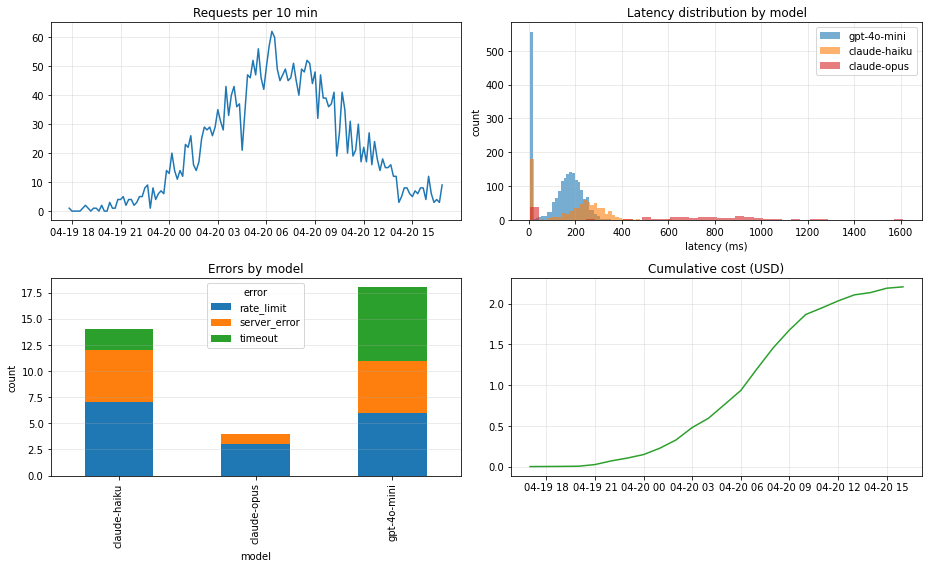

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Panel 1: requests per minute over the day
rpm = df.set_index("datetime").groupby(pd.Grouper(freq="10min"))["request_id"].count()
axes[0, 0].plot(rpm.index, rpm.values, color="tab:blue")
axes[0, 0].set_title("Requests per 10 min"); axes[0, 0].grid(alpha=0.3)

# Panel 2: latency histogram
for m, c in zip(MODELS, ["tab:blue", "tab:orange", "tab:red"]):
    axes[0, 1].hist(df[df.model == m].latency_ms, bins=40, alpha=0.6, label=m, color=c)
axes[0, 1].set_xlabel("latency (ms)"); axes[0, 1].set_ylabel("count")
axes[0, 1].set_title("Latency distribution by model"); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# Panel 3: error breakdown
err_counts = df[df.error.notna()].groupby(["model", "error"]).size().unstack(fill_value=0)
err_counts.plot(kind="bar", stacked=True, ax=axes[1, 0])
axes[1, 0].set_title("Errors by model"); axes[1, 0].set_ylabel("count"); axes[1, 0].grid(alpha=0.3, axis="y")

# Panel 4: cost over the day (cumulative)
cost_hourly = df.set_index("datetime").groupby(pd.Grouper(freq="1h"))["cost_usd"].sum()
axes[1, 1].plot(cost_hourly.index, cost_hourly.cumsum().values, color="tab:green")
axes[1, 1].set_title("Cumulative cost (USD)"); axes[1, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 7. Alerts — a hand-rolled rule engine
Real alerting runs in Alertmanager / PagerDuty. The logic fits on one screen: a rule has a window, a condition, and a severity.

In [8]:
def check_alerts(df, window=pd.Timedelta("15min")):
    now = df["datetime"].max()
    recent = df[df["datetime"] >= now - window]
    fired = []

    err_rate = recent["error"].notna().mean() if len(recent) else 0
    if err_rate > 0.05:
        fired.append((("CRITICAL", "error_rate_high"),
                      f"error rate = {err_rate:.1%} over the last {window} (> 5%)"))

    p95 = recent["latency_ms"].quantile(0.95) if len(recent) else 0
    if p95 > 3000:
        fired.append((("CRITICAL", "latency_p95_high"),
                      f"latency p95 = {p95:.0f} ms (> 3000 ms)"))
    elif p95 > 1500:
        fired.append((("WARNING", "latency_p95_elevated"),
                      f"latency p95 = {p95:.0f} ms (> 1500 ms)"))

    cost_per_hour = recent["cost_usd"].sum() * (pd.Timedelta("1h") / window)
    baseline = df["cost_usd"].sum() / 24
    if cost_per_hour > 2 * baseline and baseline > 0:
        fired.append((("CRITICAL", "cost_spike"),
                      f"cost/h projection = ${cost_per_hour:.2f} vs ${baseline:.2f} baseline"))

    cache = recent["cache_hit"].mean() if len(recent) else 0
    if cache < 0.1:
        fired.append((("WARNING", "cache_hit_low"), f"cache hit rate = {cache:.1%} (< 10%)"))

    return fired

alerts = check_alerts(df)
if not alerts:
    print("no alerts in the last 15-min window")
for (sev, name), msg in alerts:
    print(f"[{sev:<8}] {name:<24} :: {msg}")

no alerts in the last 15-min window


## 8. Debug one slow request via its trace
Pick the 99th-percentile request and inspect its trace tree. In production the same query is a single Grafana click.

In [9]:
# Take the request whose latency is at the 99th percentile
p99 = df["latency_ms"].quantile(0.99)
slow = df.iloc[(df["latency_ms"] - p99).abs().argsort().iloc[0]]
print(f"slow request: {slow['request_id']}   model={slow['model']}   latency={slow['latency_ms']} ms  "
      f"cost=${slow['cost_usd']:.4f}   error={slow['error']}")
print("input_tokens :", slow["input_tokens"])
print("output_tokens:", slow["output_tokens"])
# Replay this request through the tracer to see the breakdown (in-memory — tracer was reset above)
tracer = Tracer()
rag_call(slow["user_id"], "Replay synthetic slow query", model=slow["model"],
         cache_hit=slow["cache_hit"], rng=random.Random(hash(slow["request_id"])))
print_trace(tracer.traces[-1])

slow request: req_ccacb36b   model=claude-opus   latency=929 ms  cost=$0.0119   error=None
input_tokens : 403
output_tokens: 78
└─ handle_query (689ms)  model=claude-opus  user_id=u055  cost_usd=0.006839999999999999  latency_ms=688  cache_hit=False
  └─ embed_query (10ms)  
  └─ vector_search (18ms)  result.count=5
  └─ build_prompt (0ms)  
  └─ llm_generate (661ms)  llm.model=claude-opus  llm.input_tokens=16  llm.output_tokens=88


## 9. Privacy note — what never goes into logs
`input_tokens` is safe (a count). `prompt_variables` often contains PII — the next lesson (9-4) covers redaction.

In [10]:
FIELDS = list(asdict(LLMRequest(
    ts=0, request_id="", trace_id="", user_id="", model="", prompt_template="",
    input_tokens=0, output_tokens=0, latency_ms=0, cost_usd=0.0, cache_hit=False, error=None,
)).keys())
print("fields we log   :", FIELDS)
print("fields we never logs: ['prompt', 'response', 'retrieved_chunks']  <- require redaction first")

fields we log   : ['ts', 'request_id', 'trace_id', 'user_id', 'model', 'prompt_template', 'input_tokens', 'output_tokens', 'latency_ms', 'cost_usd', 'cache_hit', 'error', 'feedback']
fields we never logs: ['prompt', 'response', 'retrieved_chunks']  <- require redaction first


## 10. Quick checks

In [11]:
# Schema completeness
assert set(df.columns).issuperset({"ts", "model", "latency_ms", "cost_usd", "cache_hit", "error"})
# Cache hits cost nothing
assert (df.loc[df["cache_hit"], "cost_usd"] == 0).all()
# Opus is pricier per request than mini on average
cost_by_model = df[~df["cache_hit"]].groupby("model")["cost_usd"].mean()
assert cost_by_model["claude-opus"] > cost_by_model["gpt-4o-mini"]
# p95 > p50 by construction (both positive)
assert per_model["lat_p95"].gt(per_model["lat_p50"]).all()
# Alert engine returns a list (possibly empty)
assert isinstance(alerts, list)
print("OK — schema, metrics, traces, and alert rules all behave.")

OK — schema, metrics, traces, and alert rules all behave.


## Reflection questions

1. Our log schema stores token counts but not the actual prompt. Name two legitimate reasons to also log the prompt, and two reasons not to.
2. Alerting on "cost > 2x baseline" is reactive. Describe a *predictive* rule that catches the cost spike before it hits 2x.
3. For a 20-step agent, the flat trace is hard to read. Sketch the shape of a visualisation that stays readable at 20 spans.
4. Sampling: do you really need to trace every request in production? What sampling scheme would you choose?

## References
- Source theory: [`9-1-observability.mdx`](../../llm-quest-theory/level-9/9-1-observability.mdx)
- Next: [`9-2-cost-latency`](9-2-cost-latency.ipynb)